In [1]:
#Cell 1--Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, brier_score_loss,
    log_loss
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Cell 2--Load Data
train_path = '/Users/codylewis/Desktop/AIHC 5615/Week 8/heart-disease-complete-train.csv'
test_path  = '/Users/codylewis/Desktop/AIHC 5615/Week 8/heart-disease-complete-test.csv'

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (576, 15)
Test shape: (144, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,clinic,hd
0,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,NaN,NaN,hung,1
1,62.0,0.0,4.0,124.0,209.0,0.0,0.0,163.0,0.0,0.0,1.0,0.0,3.0,clev,0
2,60.0,1.0,3.0,115.0,0.0,NaN,0.0,143.0,0.0,2.4,1.0,NaN,NaN,swit,1
3,65.0,1.0,4.0,160.0,0.0,1.0,1.0,122.0,0.0,NaN,NaN,NaN,7.0,swit,1
4,34.0,1.0,1.0,118.0,182.0,0.0,2.0,174.0,0.0,0.0,1.0,0.0,3.0,clev,0


In [3]:
# Cell 3-— Identify Variable Types
target = "hd"

num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal", "clinic", "ca"]

print("Numeric predictors:", num_cols)
print("Categorical predictors:", cat_cols)




Numeric predictors: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical predictors: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'clinic', 'ca']


In [4]:
# Cell 3A— Replace unrealistic zero values with NaN
cols_with_invalid_zero = ["chol", "trestbps"]

for col in cols_with_invalid_zero:
    train_df[col] = train_df[col].replace(0, np.nan)
    test_df[col]  = test_df[col].replace(0, np.nan)

print("Zero → NaN conversion complete.")
train_df[cols_with_invalid_zero].describe()


Zero → NaN conversion complete.


,chol,trestbps
count,457.000000,574.000000
mean,246.547046,131.503484
std,58.125304,18.510008
min,85.000000,80.000000
25%,209.000000,120.000000
50%,240.000000,130.000000
75%,275.000000,140.000000
max,603.000000,200.000000


In [5]:
#Cell 4--Handle Missing Values and print out how many missing values are left
train_df_clean = train_df.copy()
test_df_clean  = test_df.copy()

# Numeric: median
for c in num_cols:
    median_val = train_df_clean[c].median()
    train_df_clean[c] = train_df_clean[c].fillna(median_val)
    test_df_clean[c]  = test_df_clean[c].fillna(median_val)

# Categorical: mode
for c in cat_cols:
    mode_val = train_df_clean[c].mode()[0]
    train_df_clean[c] = train_df_clean[c].fillna(mode_val)
    test_df_clean[c]  = test_df_clean[c].fillna(mode_val)

train_df_clean.isna().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
clinic      0
hd          0
dtype: int64

In [6]:
#Cell 5--Show Cleaned Data
# Show full cleaned training data with no truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

train_df_clean


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,clinic,hd
0,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,0.0,3.0,hung,1
1,62.0,0.0,4.0,124.0,209.0,0.0,0.0,163.0,0.0,0.0,1.0,0.0,3.0,clev,0
2,60.0,1.0,3.0,115.0,240.0,0.0,0.0,143.0,0.0,2.4,1.0,0.0,3.0,swit,1
3,65.0,1.0,4.0,160.0,240.0,1.0,1.0,122.0,0.0,0.2,2.0,0.0,7.0,swit,1
4,34.0,1.0,1.0,118.0,182.0,0.0,2.0,174.0,0.0,0.0,1.0,0.0,3.0,clev,0
5,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,clev,0
6,57.0,1.0,4.0,152.0,274.0,0.0,0.0,88.0,1.0,1.2,2.0,1.0,7.0,clev,1
7,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,clev,1
8,35.0,1.0,4.0,126.0,282.0,0.0,2.0,156.0,1.0,0.0,1.0,0.0,7.0,clev,1
9,51.0,0.0,3.0,130.0,256.0,0.0,2.0,149.0,0.0,0.5,1.0,0.0,3.0,clev,0


In [7]:
#Cell 6--Outlier Handling (Do NOT clip age)
train_clip = train_df_clean.copy()
test_clip  = test_df_clean.copy()

# Only clip variables where extreme values are likely errors
clip_cols = ["trestbps", "chol", "thalach", "oldpeak"]

low = train_clip[clip_cols].quantile(0.01)
high = train_clip[clip_cols].quantile(0.99)

# Track number of clipped values for reporting
clipped_counts = {}

for c in clip_cols:
    before = train_clip[c].copy()

    train_clip[c] = train_clip[c].clip(lower=low[c], upper=high[c])
    test_clip[c]  = test_clip[c].clip(lower=low[c], upper=high[c])

    clipped_counts[c] = (before != train_clip[c]).sum()

print("Number of clipped values:")
print(clipped_counts)

train_clip.describe()




Number of clipped values:
{'trestbps': np.int64(9), 'chol': np.int64(11), 'thalach': np.int64(11), 'oldpeak': np.int64(9)}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,51.921875,0.748264,3.180556,131.380208,244.365451,0.098958,0.595486,141.292535,0.333333,0.778993,1.791667,0.309028,4.154514,0.500000
std,9.413356,0.434388,0.957553,17.910416,46.230791,0.298866,0.841064,24.840993,0.471814,1.012685,0.512454,0.721102,1.768934,0.500435
min,28.000000,0.000000,1.000000,95.000000,147.000000,0.000000,0.000000,82.000000,0.000000,-0.850000,1.000000,0.000000,3.000000,0.000000
25%,45.000000,0.000000,2.000000,120.000000,216.750000,0.000000,0.000000,124.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,53.000000,1.000000,4.000000,130.000000,240.000000,0.000000,0.000000,143.000000,0.000000,0.200000,2.000000,0.000000,3.000000,0.500000
75%,58.000000,1.000000,4.000000,140.000000,265.250000,0.000000,1.000000,160.000000,1.000000,1.425000,2.000000,0.000000,6.000000,1.000000
max,77.000000,1.000000,4.000000,182.500000,409.750000,1.000000,2.000000,187.250000,1.000000,4.000000,3.000000,3.000000,7.000000,1.000000


In [8]:
#Cell 7--Define X and Y for modeling
X_train = train_clip.drop(columns=[target])
y_train = train_clip[target]

X_test  = test_clip.copy()


In [9]:
# Cell 8 -- Preprocessing pipeline for modeling WITH POLYNOMIALS on numeric predictors

# numeric pipeline: create polynomial features, then scale them
num_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ("scaler", StandardScaler())
])


preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])


In [10]:
#Cell 9-- Fit Candidate models
full_model = Pipeline([
    ("prep", preprocess),
    ("logreg", LogisticRegression(max_iter=500, penalty=None))
])

full_model.fit(X_train, y_train)

full_pred = full_model.predict_proba(X_train)[:, 1]



In [11]:
# Clean data for Statsmodels forward selection

# 1. Make a copy
train_fs = train_clip.copy()

# 2. Convert numeric-looking strings to actual numbers
for col in num_cols:
    train_fs[col] = pd.to_numeric(train_fs[col], errors="coerce")

# 3. Convert categorical columns to dtype category
for col in cat_cols:
    train_fs[col] = train_fs[col].astype("category")

# 4. Re-align y
y_fs = train_fs["hd"]


In [12]:
#Cell 10--Forward Selection to Find 6 Best Predictors
import statsmodels.api as sm

candidate_predictors = num_cols + cat_cols
selected = []
remaining = candidate_predictors.copy()

best_aic = np.inf

for _ in range(6):

    scores = []
    for var in remaining:
        trial_vars = selected + [var]
        
        # *** USE CLEANED DATASET ***
        X_trial = pd.get_dummies(train_fs[trial_vars], drop_first=True)
        
        # Convert to numeric array to avoid dtype object
        X_trial = X_trial.apply(pd.to_numeric, errors="coerce").astype(float)
        
        # Add intercept
        X_trial = sm.add_constant(X_trial)

        # *** USE CLEANED TARGET ***
        model = sm.GLM(y_fs.astype(float), X_trial, family=sm.families.Binomial())
        result = model.fit()

        scores.append((result.aic, var))
    
    scores.sort()
    best_aic, best_var = scores[0]
    selected.append(best_var)
    remaining.remove(best_var)

print("Selected predictors:", selected)



Selected predictors: ['cp', 'clinic', 'oldpeak', 'thal', 'ca', 'exang']


In [13]:
#Cell 11--Six-Predictor Logistic Regression
six_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), [c for c in selected if c in num_cols]),
        ("cat", OneHotEncoder(drop="first"), [c for c in selected if c in cat_cols])
    ]
)

six_model = Pipeline([
    ("prep", six_preprocess),
    ("logreg", LogisticRegression(max_iter=500))
])

six_model.fit(X_train[selected], y_train)

six_pred = six_model.predict_proba(X_train[selected])[:, 1]

metrics_six = {
    "Accuracy": accuracy_score(y_train, six_model.predict(X_train[selected])),
    "AUC": roc_auc_score(y_train, six_pred),
    "Brier": brier_score_loss(y_train, six_pred),
    "LogLoss": log_loss(y_train, six_pred)
}

metrics_six


{'Accuracy': 0.8576388888888888,
 'AUC': 0.9274872202932098,
 'Brier': 0.10777610802018679,
 'LogLoss': 0.349486801300362}

/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/

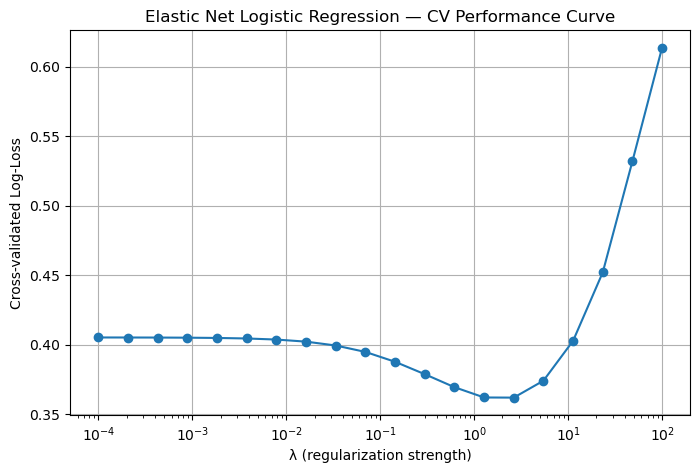

Best lambda: 2.6366508987303554
Best C: 0.37926901907322536


In [14]:
#Cell 13-- Cross-validation
lambdas = np.logspace(-4, 2, 20)
cv_scores = []

for C in 1 / lambdas:
    model = Pipeline([
        ("prep", preprocess),
        ("logreg", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=C,
            max_iter=2000
        ))
    ])
    
    score = -np.mean(
        cross_val_score(model, X_train, y_train, cv=5, scoring="neg_log_loss")
    )
    cv_scores.append(score)

plt.figure(figsize=(8,5))
plt.semilogx(lambdas, cv_scores, marker="o")
plt.xlabel("λ (regularization strength)")
plt.ylabel("Cross-validated Log-Loss")
plt.title("Elastic Net Logistic Regression — CV Performance Curve")
plt.grid(True)
plt.show()
# Find best lambda based on lowest CV log-loss
idx_best = int(np.argmin(cv_scores))
best_lambda = lambdas[idx_best]
best_C = 1.0 / best_lambda

print("Best lambda:", best_lambda)
print("Best C:", best_C)


In [15]:
# Cell 13A -- Tune l1_ratio + C together

l1_options = [0.1, 0.3, 0.5, 0.7, 0.9]   
lambdas = np.logspace(-4, 2, 12)       

results = []

for l1 in l1_options:
    for lam in lambdas:
        C = 1.0 / lam
        model = Pipeline([
            ("prep", preprocess),
            ("logreg", LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                l1_ratio=l1,
                C=C,
                max_iter=2000
            ))
        ])
        score = -np.mean(
            cross_val_score(model, X_train, y_train, cv=5, scoring="neg_log_loss")
        )
        results.append((score, l1, C))

# pick best combo
best_score, best_l1, best_C = min(results, key=lambda x: x[0])

print("Best CV log-loss:", best_score)
print("Best l1_ratio:", best_l1)
print("Best C:", best_C)


/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/ai-class/

Best CV log-loss: 0.36073516548089624
Best l1_ratio: 0.9
Best C: 0.43287612810830617


In [16]:
#Cell 12--Elastic Net Logistic Regression (FINAL MODEL)
final_model = Pipeline([
    ("prep", preprocess),
    ("logreg", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=best_l1,   # from Cell 13A
        C=best_C,           # from Cell 13A
        max_iter=2000
    ))
])


final_model.fit(X_train, y_train)

final_pred_train = final_model.predict_proba(X_train)[:, 1]

metrics_final = {
    "Accuracy": accuracy_score(y_train, final_model.predict(X_train)),
    "AUC": roc_auc_score(y_train, final_pred_train),
    "Brier": brier_score_loss(y_train, final_pred_train),
    "LogLoss": log_loss(y_train, final_pred_train)
}

metrics_final



{'Accuracy': 0.8715277777777778,
 'AUC': 0.9346908757716049,
 'Brier': 0.09853711521978144,
 'LogLoss': 0.3263567874211245}

In [17]:
# Cell 12A -- Compare linear vs polynomial elastic net

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, log_loss

# 1. Linear-only preprocess (no polynomials)
preprocess_linear = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model_linear = Pipeline([
    ("prep", preprocess_linear),
    ("logreg", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=best_l1,   # use tuned l1_ratio
        C=best_C,           # use tuned C as well
        max_iter=2000
    ))
])


model_linear.fit(X_train, y_train)
pred_linear = model_linear.predict_proba(X_train)[:, 1]

metrics_linear = {
    "Accuracy": accuracy_score(y_train, model_linear.predict(X_train)),
    "AUC": roc_auc_score(y_train, pred_linear),
    "Brier": brier_score_loss(y_train, pred_linear),
    "LogLoss": log_loss(y_train, pred_linear)
}

# 2. Polynomial model (uses your existing final_model with polynomial preprocess)
pred_poly = final_model.predict_proba(X_train)[:, 1]

metrics_poly = {
    "Accuracy": accuracy_score(y_train, final_model.predict(X_train)),
    "AUC": roc_auc_score(y_train, pred_poly),
    "Brier": brier_score_loss(y_train, pred_poly),
    "LogLoss": log_loss(y_train, pred_poly)
}

metrics_linear, metrics_poly


({'Accuracy': 0.8715277777777778,
  'AUC': 0.9339192708333334,
  'Brier': 0.09914330240253309,
  'LogLoss': 0.32823578235451656},
 {'Accuracy': 0.8715277777777778,
  'AUC': 0.9346908757716049,
  'Brier': 0.09853711521978144,
  'LogLoss': 0.3263567874211245})

In [18]:
#Cell 14--Test Predictions

test_pred_prob = final_model.predict_proba(X_test)[:, 1]
test_pred_binary = (test_pred_prob >= 0.5).astype(int)

pred_df = pd.DataFrame({
    "probability": test_pred_prob,
    "prediction": test_pred_binary
})

pred_df.head()



,probability,prediction
0,0.149624,0
1,0.991437,1
2,0.037200,0
3,0.527519,1
4,0.192631,0


In [19]:
#Cell 15 -- Extract and Display Coefficients (with polynomial terms)

# 1. Get polynomial feature names for numeric predictors
num_poly_features = final_model.named_steps["prep"] \
    .named_transformers_["num"] \
    .named_steps["poly"] \
    .get_feature_names_out(num_cols)

# 2. Get encoded categorical feature names
encoded_cat = final_model.named_steps["prep"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

# 3. Combine in the same order as the ColumnTransformer output
final_features = list(num_poly_features) + list(encoded_cat)

# 4. Get coefficients from logistic regression
coef = final_model.named_steps["logreg"].coef_[0]

coef_df = pd.DataFrame({
    "feature": final_features,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)

coef_df



,feature,coefficient
41,clinic_swit,2.586574
25,cp_4.0,1.488540
34,slope_2.0,0.854379
32,exang_1.0,0.446988
38,thal_7.0,0.446137
21,sex_1.0,0.420972
13,trestbps oldpeak,0.420486
19,oldpeak^2,0.293666
43,ca_1.0,0.172626
27,fbs_1.0,0.142168


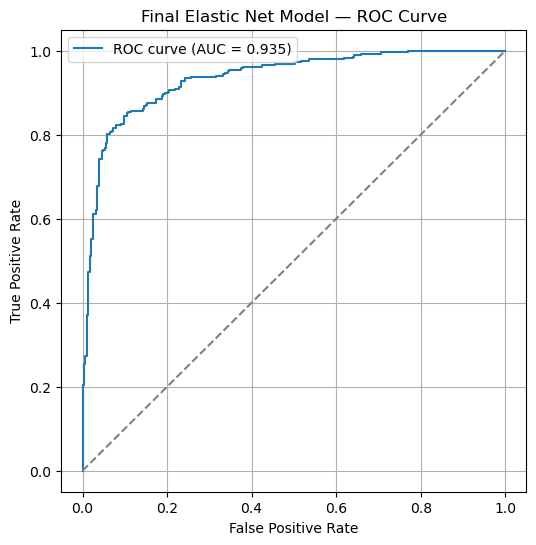

In [20]:
#Cell 16-- ROC Curve for Final Model

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_train, final_pred_train)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Elastic Net Model — ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


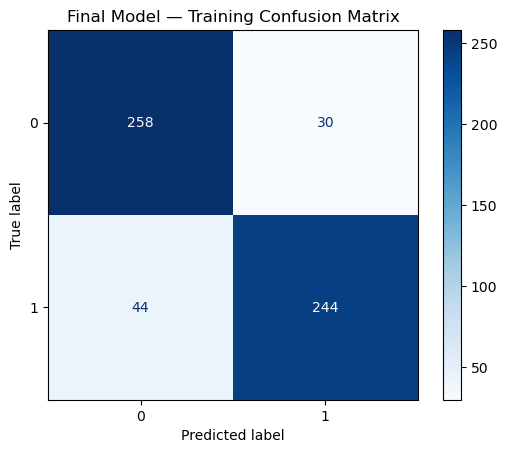

In [21]:
#Cell 17-- Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_train, final_model.predict(X_train))
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Final Model — Training Confusion Matrix")
plt.show()


In [22]:
#Cell 18--Save Prediction CSV
pred_df.to_csv("cody_predictions.csv", index=False)
print("Saved cody_predictions.csv!")


Saved cody_predictions.csv!


In [23]:
#Cell 19- Print Final
print(final_model)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'thal', 'clinic', 'ca'])])),
                ('logreg',
            

In [24]:
print("best_l1:", best_l1)
print("best_C:", best_C)


best_l1: 0.9
best_C: 0.43287612810830617


In [25]:
logreg = final_model.named_steps["logreg"]
print("Final model C:", logreg.C)
print("Final model l1_ratio:", logreg.l1_ratio)


Final model C: 0.43287612810830617
Final model l1_ratio: 0.9
